In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from pickle import load

import re
from tqdm import tqdm

import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    # Use LaTeX
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Lines
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 1,

    # Ticks
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # Save figures
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

In [2]:
DATA_PATH = 'data/'
FILE_NAME = 'closed_shell_results.pickle'
LOG_FILE = 'closed_shell_calculations.log'

log = open(DATA_PATH + LOG_FILE, 'r').readlines()
closed_shell = load(open(DATA_PATH + FILE_NAME, 'rb'))

# Run Time analysis

In [3]:
elapsed_time = []
for line in log:
    match_string = re.search(r'elapsed \| (\d+h \d+m \d+\.\d+s)\n', line)
    if match_string:
        match_string = match_string.group(1)
        hours = re.search(r'(\d+)h', match_string).group(1)
        minutes = re.search(r'(\d+)m', match_string).group(1)
        seconds = re.search(r'(\d+\.\d+)s', match_string).group(1)

        elapsed_time.append(float(hours) * 3600 + float(minutes) * 60 + float(seconds))

time_per_calculation = []
for i, result in enumerate(closed_shell['runs']):
        time_per_calculation.append(np.diff([0] + elapsed_time[i * len(result['points']):(i + 1) * len(result['points'])]))

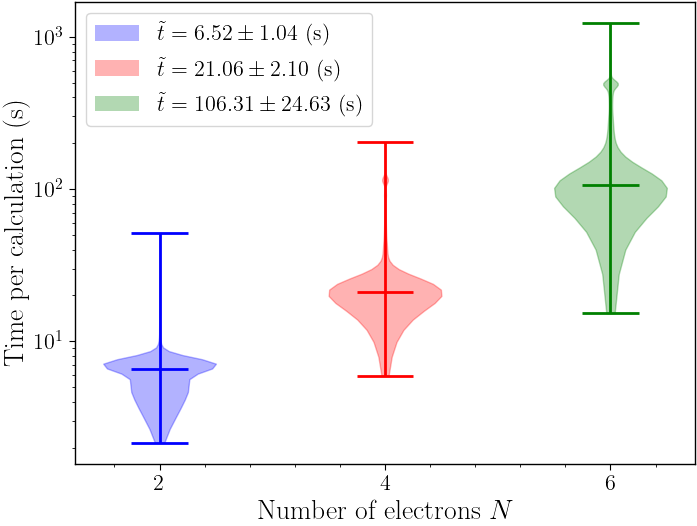

In [4]:
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

fig, ax = plt.subplots(figsize=(8, 6))
plots = []
labels = []
for i, result in enumerate(closed_shell['runs']):
    # add label with median and MAD
    median = np.median(time_per_calculation[i])
    mad = np.median(np.abs(time_per_calculation[i] - median))
    
    parts = ax.violinplot(time_per_calculation[i], positions=[i], showmeans=False, showmedians=True, showextrema=True)
    color = colors[i % len(colors)]

    # Color the violin body
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(0.3)

    # Color the median, min/max and bars
    for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        if key in parts:
            parts[key].set_color(color)
            parts[key].set_linewidth(2)

    # Rectangle for the median
    plots.append(Rectangle((0, 0), 1, 1, fc=color, alpha=0.3))
    labels.append(f"$\\tilde{{t}} = {median:.2f} \pm {mad:.2f}$ (s)")

ax.set_xticks(range(len(closed_shell['runs'])))
ax.set_xticklabels([f"${2*i}$" for i in range(1, len(closed_shell['runs'])+1)])
ax.set_ylabel('Time per calculation (s)')
ax.set_yscale('log')
ax.legend(plots, labels, loc='upper left')
ax.set_xlabel('Number of electrons $N$')

fig.savefig('Figures/time_per_calculation.pdf', dpi=600)

5050it [00:00, 234362.73it/s]
5050it [00:00, 255414.09it/s]
5050it [00:00, 258901.32it/s]


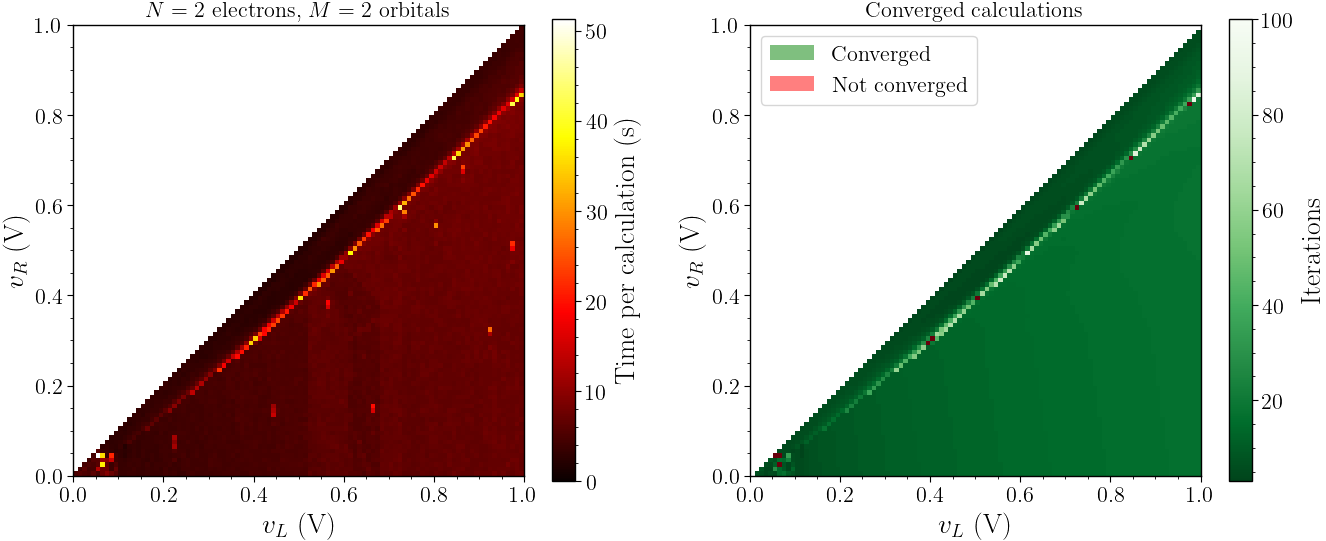

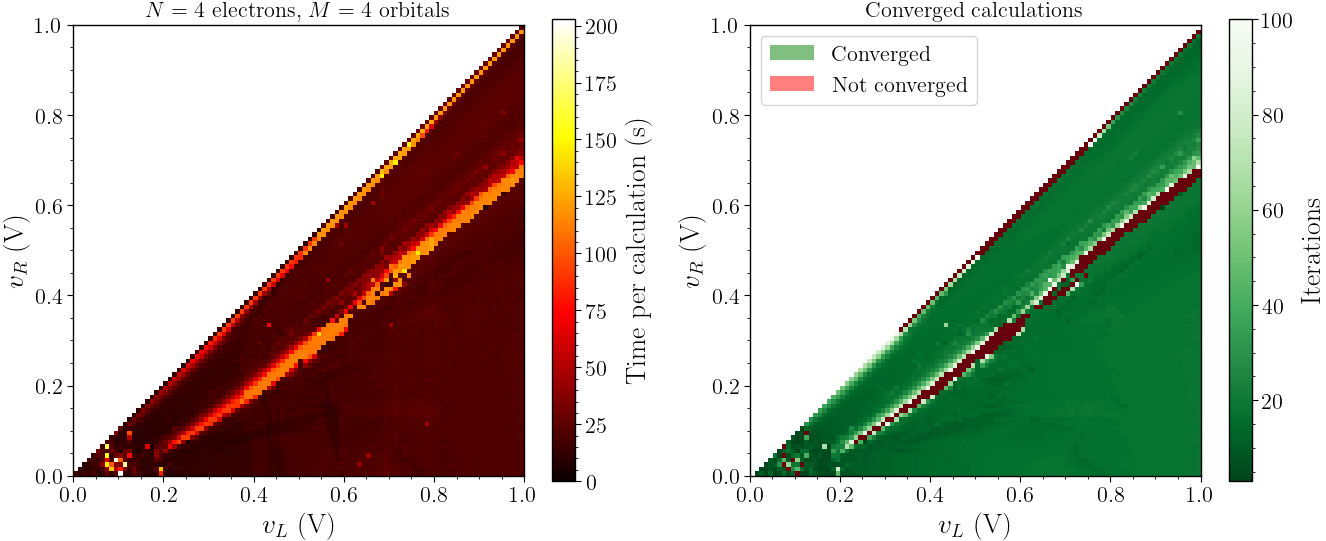

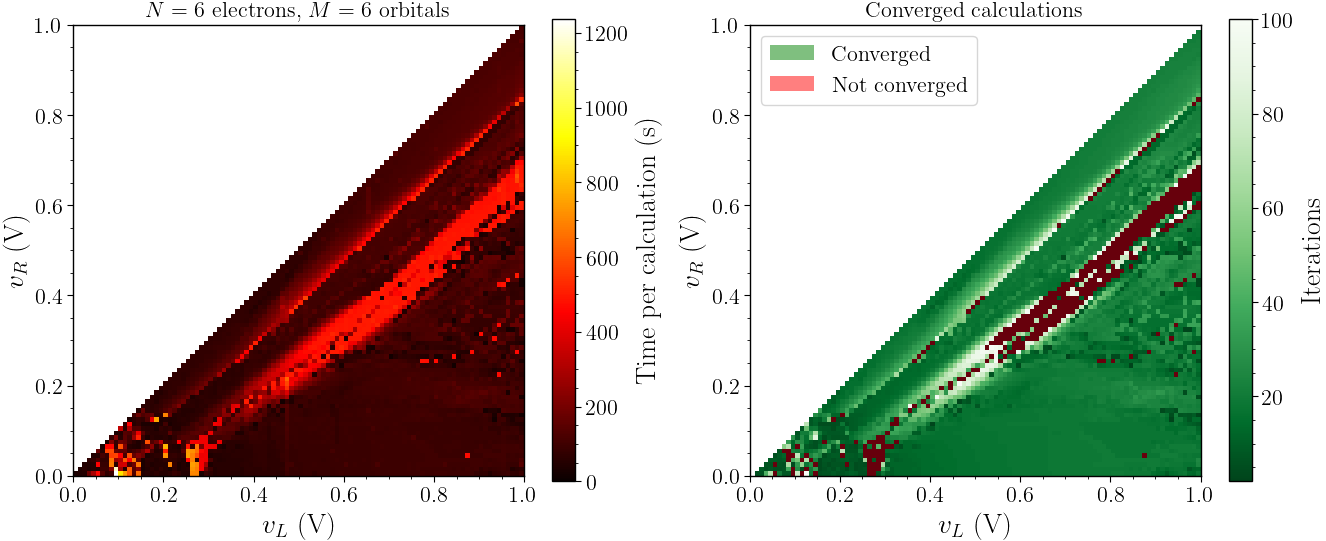

In [10]:
cmap = sns.color_palette("hot", as_cmap=True)

Vs = np.linspace(0, 1, 100)

energy_meshes = []

for i, result in enumerate(closed_shell['runs']):
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    times = time_per_calculation[i]
    max_time = np.max(times)

    times_mesh = np.zeros((len(Vs), len(Vs)))
    energy_mesh = np.zeros((len(Vs), len(Vs)))
    iterations_mesh = np.zeros((len(Vs), len(Vs)))
    converged_mesh = np.zeros((len(Vs), len(Vs)))

    for j, point in tqdm(enumerate(result['points'])):
        vx = point['vx']
        vy = point['vy']
        t = times[j]

        ix = np.argmin(np.abs(Vs - vx))
        iy = np.argmin(np.abs(Vs - vy))
        times_mesh[ix, iy] = t
        energy_mesh[ix, iy] = point['energy']
        energy_mesh[iy, ix] = point['energy']
        iterations_mesh[ix, iy] = point['iterations']
        iterations_mesh[iy, ix] = np.nan
        converged_mesh[ix, iy] = not point['converged']
        converged_mesh[iy, ix] = np.nan

    energy_meshes.append(energy_mesh)
    times_mesh[times_mesh == 0] = np.nan
    converged_mesh[converged_mesh == 0] = np.nan

    ax = axs[0]
    im = ax.imshow(times_mesh.T, origin='lower', extent=(0, 1, 0, 1), cmap=cmap, vmin=0, vmax=max_time)
    fig.colorbar(im, ax=ax, label='Time per calculation (s)')

    ax.set_xlabel('$v_L$ (V)')
    ax.set_ylabel('$v_R$ (V)')
    ax.set_title(f'$N={2*(i+1)}$ electrons, $M={2*(i+1)}$ orbitals')

    ax = axs[1]
    im = ax.imshow(iterations_mesh.T, origin='lower', extent=(0, 1, 0, 1), cmap='Greens_r')
    fig.colorbar(im, ax=ax, label='Iterations')

    ax.imshow(converged_mesh.T, origin='lower', extent=(0, 1, 0, 1), cmap='Reds', vmin=0, vmax=1)

    ax.set_xlabel('$v_L$ (V)')
    ax.set_ylabel('$v_R$ (V)')
    ax.set_title("Converged calculations")

    lines = [Rectangle((0, 0), 1, 1, fc='green', alpha=0.5),
             Rectangle((0, 0), 1, 1, fc='red', alpha=0.5)]
    labels = ['Converged', 'Not converged']
    ax.legend(lines, labels, loc='upper left')
    fig.savefig(f'Figures/closed_shell_N{2*(i+1)}_M{2*(i+1)}.pdf', dpi=600)

# Charge stability

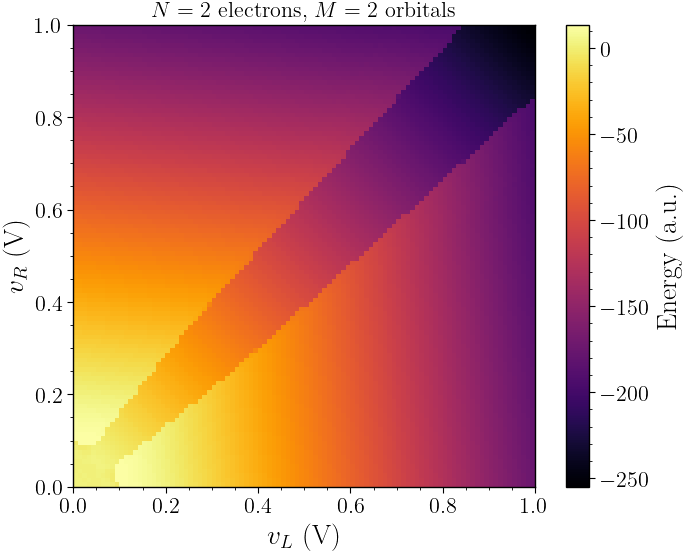

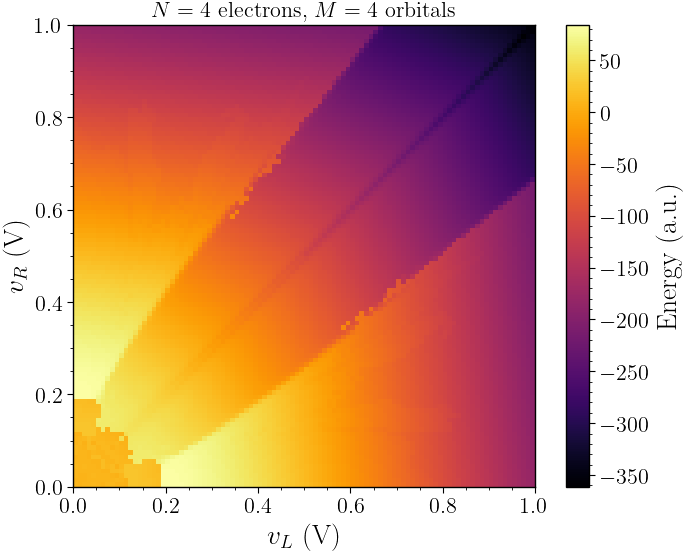

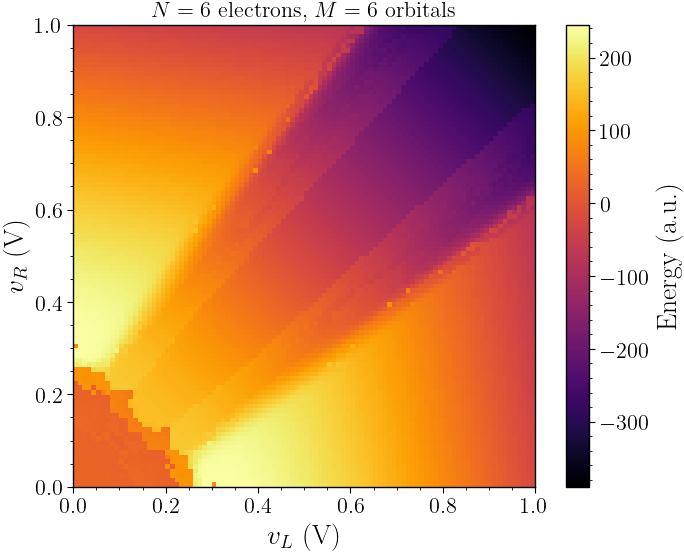

In [6]:
cmap = sns.color_palette("inferno", as_cmap=True)

charge_stability_mesh = np.zeros((len(Vs), len(Vs)))
prev_mesh = None

for i, energy_mesh in enumerate(energy_meshes):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(energy_mesh.T, origin='lower', extent=(0, 1, 0, 1), cmap=cmap)
    fig.colorbar(im, ax=ax, label='Energy (a.u.)')

    ax.set_xlabel('$v_L$ (V)')
    ax.set_ylabel('$v_R$ (V)')
    ax.set_title(f'$N={2*(i+1)}$ electrons, $M={2*(i+1)}$ orbitals')

    if prev_mesh is not None:
        charge_stability_mesh[energy_mesh < prev_mesh] = 2**(i+1)

    prev_mesh = energy_mesh

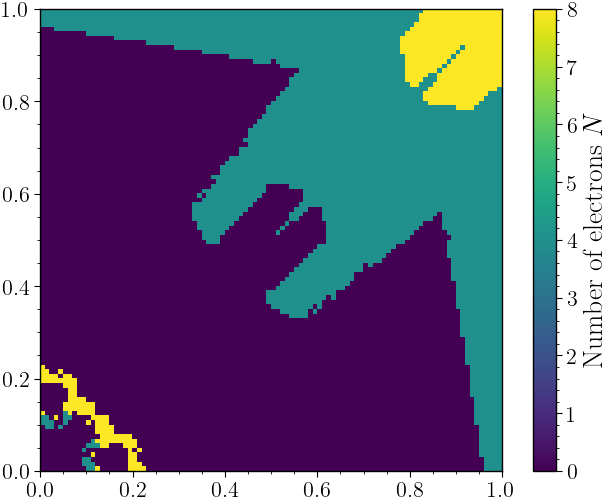

In [7]:
# This cmap should be categorical, the mesh has only 3 classes
cmap = sns.color_palette("viridis", as_cmap=True)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(charge_stability_mesh.T, origin='lower', extent=(0, 1, 0, 1), cmap=cmap)
fig.colorbar(im, ax=ax, label='Number of electrons $N$')